# 1). Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# 2). Load Data

In [2]:
df=pd.read_csv("/workspaces/Predicting_Companies-_Bankruptcy_in_Taiwan-Ensemble-Modelling-/data/taiwanese+bankruptcy+prediction.zip")
df.head(3)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474


# 3). Split

In [3]:
# Feature-target split
target="Bankrupt?"
X=df.drop(columns=target)
y=df[target]
print("X", X.shape)
print("y", y.shape)

X (6819, 95)
y (6819,)


In [4]:
# Randomized train test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (5455, 95)
y_train (5455,)
X_test (1364, 95)
y_test (1364,)


# 4) Resample

In [5]:
under_sampler=RandomUnderSampler(random_state=42)
X_train_under, y_train_under=under_sampler.fit_resample(X_train, y_train)
print("X_train_under", X_train_under.shape)
print("y_train_under", y_train_under.shape)
over_sampler=RandomOverSampler(random_state=42)
X_train_over, y_train_over=over_sampler.fit_resample(X_train, y_train)
print("X_train_over", X_train_over.shape)
print("X_train_over", X_train_over.shape)

X_train_under (338, 95)
y_train_under (338,)
X_train_over (10572, 95)
X_train_over (10572, 95)


# 5). Build Models

## Baselining

In [6]:
baseline_acc=df["Bankrupt?"].value_counts(normalize=True).max()
print("Baseline accuracy:",round(baseline_acc, 2))

Baseline accuracy: 0.97


##  Random Forest Models

In [7]:
# Instantiate classifier
clf=RandomForestClassifier(random_state=42)
# Cross validation
cv_acc_scores=cross_val_score(clf, X_train, y_train, cv=5, n_jobs=-1)
print(cv_acc_scores)

[0.96975252 0.9715857  0.97433547 0.97341888 0.97250229]


In [8]:
# Grid Search
# Set Parameters
params = {
    "n_estimators": range(25, 100, 25),
    "max_depth": range(10, 50, 10)
}
params

{'n_estimators': range(25, 100, 25), 'max_depth': range(10, 50, 10)}

In [9]:
# Instantiate and fit for all sets
# Fit on under-sampled data
model_under=GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_under.fit(X_train_under, y_train_under)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see ho

In [10]:
# Fit base model
model_base=GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_base.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see ho

In [11]:
# Fit on over-sampled data
model_over=GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_over.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see ho

In [12]:
# Extract best params from all models
print("Model_under best params:", model_under.best_params_)
print("Model_base best params:", model_base.best_params_)
print("Model_over best params:", model_over.best_params_)


Model_under best params: {'max_depth': 10, 'n_estimators': 50}
Model_base best params: {'max_depth': 20, 'n_estimators': 75}
Model_over best params: {'max_depth': 40, 'n_estimators': 50}


In [13]:
# Extract results
results_under=pd.DataFrame(model_under.cv_results_)
results_over=pd.DataFrame(model_over.cv_results_)
results_base=pd.DataFrame(model_base.cv_results_)

In [14]:
results_under.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.147549,0.014647,0.011060,0.000657,10,50,"{'max_depth': 10, 'n_estimators': 50}",0.867647,0.838235,0.882353,0.850746,0.880597,0.863916,0.017117,1
2,0.214856,0.016939,0.015270,0.002589,10,75,"{'max_depth': 10, 'n_estimators': 75}",0.867647,0.852941,0.867647,0.850746,0.880597,0.863916,0.010954,1
5,0.271532,0.075394,0.016891,0.003456,20,75,"{'max_depth': 20, 'n_estimators': 75}",0.867647,0.852941,0.867647,0.850746,0.880597,0.863916,0.010954,1
4,0.198162,0.044854,0.020721,0.009499,20,50,"{'max_depth': 20, 'n_estimators': 50}",0.867647,0.838235,0.882353,0.850746,0.880597,0.863916,0.017117,1
11,0.191516,0.024678,0.013101,0.002416,40,75,"{'max_depth': 40, 'n_estimators': 75}",0.867647,0.852941,0.867647,0.850746,0.880597,0.863916,0.010954,1


In [15]:
results_base.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,1.961903,0.031661,0.015708,0.000427,30,75,"{'max_depth': 30, 'n_estimators': 75}",0.968836,0.971586,0.973419,0.972502,0.973419,0.971952,0.001700,1
11,1.935733,0.100862,0.015026,0.001853,40,75,"{'max_depth': 40, 'n_estimators': 75}",0.968836,0.971586,0.973419,0.972502,0.973419,0.971952,0.001700,1
5,1.958367,0.087470,0.019078,0.007341,20,75,"{'max_depth': 20, 'n_estimators': 75}",0.968836,0.971586,0.973419,0.972502,0.973419,0.971952,0.001700,1
4,1.320429,0.174094,0.011988,0.000176,20,50,"{'max_depth': 20, 'n_estimators': 50}",0.969753,0.971586,0.970669,0.973419,0.971586,0.971402,0.001216,4
10,1.369081,0.106590,0.012176,0.000359,40,50,"{'max_depth': 40, 'n_estimators': 50}",0.969753,0.971586,0.970669,0.973419,0.971586,0.971402,0.001216,4


In [16]:
results_over.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
10,1.994922,0.046336,0.018611,0.002625,40,50,"{'max_depth': 40, 'n_estimators': 50}",0.992435,0.995745,0.994797,0.996216,0.995743,0.994987,0.001357,1
11,2.869863,0.191076,0.023112,0.002817,40,75,"{'max_depth': 40, 'n_estimators': 75}",0.992435,0.994799,0.994324,0.995270,0.994324,0.994230,0.000964,2
9,1.117676,0.125375,0.010614,0.000153,40,25,"{'max_depth': 40, 'n_estimators': 25}",0.992908,0.994326,0.993851,0.993851,0.994797,0.993946,0.000627,3
8,3.005769,0.194333,0.022724,0.000317,30,75,"{'max_depth': 30, 'n_estimators': 75}",0.992435,0.992908,0.993377,0.994324,0.992904,0.993190,0.000641,4
7,2.098877,0.121172,0.017773,0.001912,30,50,"{'max_depth': 30, 'n_estimators': 50}",0.992435,0.992908,0.993377,0.994324,0.992431,0.993095,0.000707,5


## Evaluate

In [17]:
print("Under sampled accuracy:", round(model_under.score(X_test, y_test),2))
print("Base accuracy:", round(model_base.score(X_test, y_test), 2))
print("Over sampled accuracy:", round(model_over.score(X_test, y_test), 2))

Under sampled accuracy: 0.86
Base accuracy: 0.97
Over sampled accuracy: 0.97


### Confusion Matrices

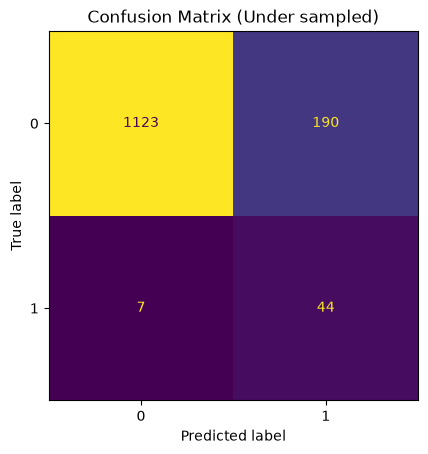

In [18]:
ConfusionMatrixDisplay.from_estimator(model_under, X_test, y_test, colorbar=None)
plt.title("Confusion Matrix (Under sampled)");

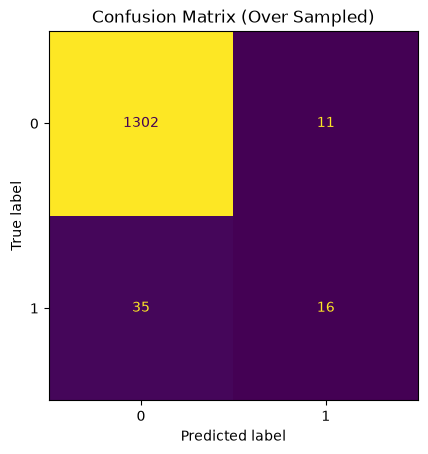

In [19]:
ConfusionMatrixDisplay.from_estimator(model_over, X_test, y_test, colorbar=None)
plt.title("Confusion Matrix (Over Sampled)");

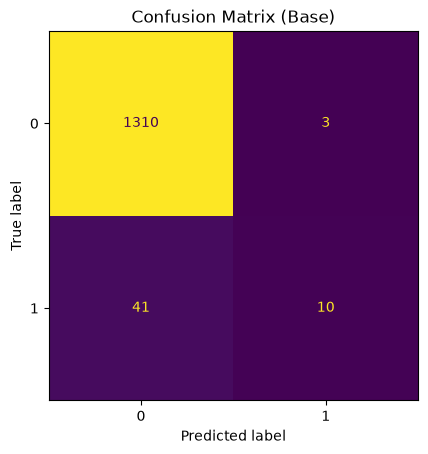

In [21]:
ConfusionMatrixDisplay.from_estimator(model_base, X_test, y_test, colorbar=None)
plt.title("Confusion Matrix (Base)");

### Classification Reports

In [ ]:
print(classification_report(y_test, model_under.predict(X_test)))


              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1313
           1       0.19      0.86      0.31        51

    accuracy                           0.86      1364
   macro avg       0.59      0.86      0.61      1364
weighted avg       0.96      0.86      0.90      1364



#### Under Sampled
This model achieves an overall accuracy of 86%, which is noticeably lower than the baseline (97%). However, in a highly imbalanced bankruptcy prediction problem, accuracy alone does not adequately reflect model effectiveness. The minority-class metrics provide a clearer picture of the model's behavior.

> i) Performance on Non-Bankrupt Companies (Class 0):

- The model maintains strong performance on healthy companies despite being trained on a reduced majority-class sample:
- Precision: 0.99 – When the model predicts a company is non-bankrupt, it is almost always correct.
- Recall: 0.86 – The model correctly identifies 86% of all non-bankrupt companies.
- F1-score: 0.92 – Indicates strong overall performance on the majority class.

While performance remains good, the reduction in recall suggests the model is more willing to classify firms as bankrupt than a model trained on the original distribution.

> ii) Performance on Bankrupt Companies (Class 1):
- The model demonstrates a very different behavior on the minority class:
- Precision: 0.19 – Only 19% of companies predicted as bankrupt are actually bankrupt.
- Recall: 0.86 – The model successfully identifies 86% of all bankrupt companies.
- F1-score: 0.31 – Reflects the trade-off between strong recall and weak precision.

The high recall indicates that the model is highly effective at detecting bankrupt firms. However, this comes at the cost of a large number of false positive predictions, meaning many healthy companies are incorrectly flagged as bankrupt.

> Macro vs Weighted Averages
- Macro Recall: 0.86
- Macro F1-score: 0.61

The macro recall is particularly notable because it shows that the model performs similarly well in identifying both classes. Unlike many imbalanced classification models, it does not ignore the minority class.

> The weighted metrics remain high:
- Weighted F1-score: 0.90. but these are still influenced by the predominance of non-bankrupt companies in the dataset.

Key Takeaway:
- The model is highly sensitive to bankrupt companies. It correctly identifies approximately 86% of all bankrupt firms, making it effective at minimizing missed bankruptcies.
- The model generates many false alarms.
- The low precision indicates that a large proportion of companies flagged as bankrupt are actually healthy.
- Under-sampling successfully reduced majority-class bias.
> The model favors recall over precision. It adopts an aggressive approach to bankruptcy detection, prioritizing the identification of potentially risky firms even if that means incorrectly flagging many healthy companies. It could be useful in situations where the cost of missing a bankrupt company is significantly greater than the cost of investigating a false positive.

> However, the large number of false bankruptcy predictions may reduce its practicality in operational settings. As a result, while the model demonstrates strong sensitivity to financial distress, further comparison with the base and oversampled models is necessary to determine whether the gain in recall justifies the loss in precision and overall accuracy.

In [ ]:
print(classification_report(y_test, model_over.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1313
           1       0.59      0.31      0.41        51

    accuracy                           0.97      1364
   macro avg       0.78      0.65      0.70      1364
weighted avg       0.96      0.97      0.96      1364



#### Over-Sampled
This model achieves an overall accuracy of 97%, indicating strong performance on the test set. However, given the severe class imbalance (97% non-bankrupt vs 3% bankrupt), the minority-class metrics provide a more meaningful assessment of model effectiveness.

> i) Performance on Non-Bankrupt Companies (Class 0)

- The model performs exceptionally well in identifying healthy companies:
- Precision: 0.97 – When the model predicts a company is non-bankrupt, it is correct 97% of the time.
- Recall: 0.99 – It successfully identifies 99% of all non-bankrupt companies.
- F1-score: 0.98 – Indicates an excellent balance between precision and recall for the majority class.

These results suggest the model has learned the characteristics of financially healthy firms very effectively and makes very few mistakes on the dominant class.

> ii) Performance on Bankrupt Companies (Class 1)

The model's ability to identify bankrupt firms is considerably weaker:
- Precision: 0.59 – Among companies predicted as bankrupt, 59% are actually bankrupt.
- Recall: 0.31 – The model identifies only 31% of all bankrupt companies.
- F1-score: 0.41 – Indicates moderate but limited effectiveness on the minority class.

The relatively high precision shows that bankruptcy predictions are reasonably reliable. However, the low recall indicates that the majority of bankrupt companies are still being missed.

> Macro vs Weighted Averages
- Macro Recall: 0.65
- Macro F1-score: 0.70

The gap between the excellent performance on Class 0 and the weaker performance on Class 1 lowers the macro averages, revealing that the model's performance is not equally strong across both classes.

Meanwhile:

- Weighted F1-score: 0.96. This remains high because the majority class dominates the dataset and therefore heavily influences weighted metrics.

Key Takeaway:
- The model effectively controls false positives. Bankruptcy predictions are relatively trustworthy, with nearly 6 out of every 10 flagged companies actually being bankrupt.
- The model still struggles with false negatives. Approximately 69% of bankrupt companies are missed, which may be problematic in a risk-management setting.
> Oversampling improved minority-class recognition without sacrificing overall accuracy. The model maintains strong performance on the majority class while achieving meaningful, though limited, detection of bankrupt firms.

> The model is conservative in predicting bankruptcy. It tends to classify companies as non-bankrupt unless there is substantial evidence to the contrary, resulting in higher precision but lower recall.
Preliminary Assessment

In [ ]:
print(classification_report(y_test, model_base.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1313
           1       0.77      0.20      0.31        51

    accuracy                           0.97      1364
   macro avg       0.87      0.60      0.65      1364
weighted avg       0.96      0.97      0.96      1364



#### Base model
This model achieves an overall accuracy of 97%, matching the oversampled model and substantially outperforming the undersampled model in terms of overall classification accuracy. 
> i). Performance on Non-Bankrupt Companies (Class 0)
The model performs exceptionally well on the majority class:
- Precision: 0.97 – When the model predicts a company is non-bankrupt, it is correct 97% of the time.
- Recall: 1.00 – The model successfully identifies virtually all non-bankrupt companies.
- F1-score: 0.98 – Indicates excellent and highly consistent performance on the majority class.
These results suggest that the model has learned the characteristics of healthy firms extremely well and makes very few mistakes when classifying non-bankrupt companies.

> ii) Performance on Bankrupt Companies (Class 1)
The model's performance on the minority class is considerably weaker:
- Precision: 0.77 – When the model predicts bankruptcy, it is correct 77% of the time.
- Recall: 0.20 – The model identifies only 20% of all bankrupt companies.
- F1-score: 0.31 – Indicates limited effectiveness in detecting bankrupt firms despite high prediction reliability.
The high precision demonstrates that bankruptcy predictions are generally trustworthy. However, the very low recall reveals that the model misses the vast majority of bankrupt companies.

> Macro vs Weighted Averages
- Macro Recall: 0.60
- Macro F1-score: 0.65
These metrics highlight the disparity between the model's excellent performance on healthy companies and its weaker performance on bankrupt firms.

Meanwhile:
- Weighted F1-score: 0.96. Remains very high because the majority class dominates the dataset and therefore contributes most heavily to the weighted averages.

Key Takeaways:
> The model is highly conservative in predicting bankruptcy. It only predicts bankruptcy when there is strong evidence, resulting in very reliable bankruptcy predictions.
> The model misses most bankrupt companies. With a recall of only 20%, approximately four out of every five bankrupt firms go undetected.

While bankruptcy predictions made by the model are highly reliable, the model fails to identify a large proportion of companies that ultimately become bankrupt. In a bankruptcy prediction setting—where the cost of missing a distressed company is often substantial—this limitation may reduce its practical value despite its strong overall accuracy and minority-class precision.

Comparative Perspective

Looking only at the minority class:

Model	Precision	Recall	F1-score
Under-sampled	0.19	0.86	0.31
Base Model	0.77	0.20	0.31
Over-sampled	0.59	0.31	0.41

This comparison suggests:

Under-sampling dramatically improves bankruptcy detection but produces many false alarms.
Base model produces highly reliable bankruptcy predictions but misses most bankrupt companies.
Over-sampling achieves the best balance between precision and recall, resulting in the highest minority-class F1-score.

Based on the evidence available so far, the oversampled model appears to be the strongest candidate for further development, as it improves bankruptcy detection relative to the base model while maintaining substantially better precision than the undersampled approach.

#### Overally:
> Across the three approaches—base (no resampling), undersampling, and oversampling, clear trade-offs emerge due to the severe class imbalance in the bankruptcy dataset. 
- The base model achieves high accuracy (0.97) and strong precision for the bankrupt class (0.77), but it fails to identify most bankrupt companies, with a very low recall of 0.20, making it conservative and biased toward the majority class. 
- The undersampled model significantly improves detection of bankrupt firms, achieving high recall (0.86), but at the cost of very low precision (0.19), meaning it produces many false alarms. 
- The oversampled model offers a more balanced compromise, maintaining high overall accuracy (0.97) while improving minority-class precision (0.59) and achieving the best F1-score (0.41), though recall remains moderate (0.31). 
> Overall, the results show that accuracy alone is misleading in this context, and the oversampled model provides the most balanced trade-off between identifying bankrupt firms and limiting false positives.

### Plot ROC curve

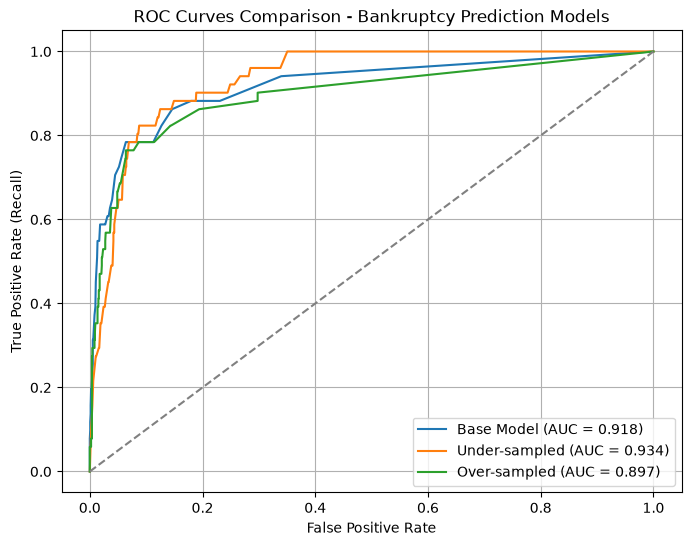

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability scores for the positive class (bankrupt = 1)
y_proba_base = model_base.predict_proba(X_test)[:, 1]
y_proba_under = model_under.predict_proba(X_test)[:, 1]
y_proba_over = model_over.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
fpr_under, tpr_under, _ = roc_curve(y_test, y_proba_under)
fpr_over, tpr_over, _ = roc_curve(y_test, y_proba_over)

# Compute AUC scores
auc_base = auc(fpr_base, tpr_base)
auc_under = auc(fpr_under, tpr_under)
auc_over = auc(fpr_over, tpr_over)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_base, tpr_base, label=f'Base Model (AUC = {auc_base:.3f})')
plt.plot(fpr_under, tpr_under, label=f'Under-sampled (AUC = {auc_under:.3f})')
plt.plot(fpr_over, tpr_over, label=f'Over-sampled (AUC = {auc_over:.3f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves Comparison - Bankruptcy Prediction Models')
plt.legend()
plt.grid(True)

plt.show()

All three models have strong discriminative power (AUC > 0.89), indicating that the dataset is highly learnable. The undersampled model achieves the best ranking performance (AUC = 0.934), suggesting superior ability to separate risky from safe firms. However, higher AUC does not directly translate to better decision-making performance, as precision-recall trade-offs show that oversampling provides a more balanced and practically useful model despite a slightly lower AUC.

#### Cohen Kappa's (K Statistic)

In [24]:
from sklearn.metrics import cohen_kappa_score

# Predictions
y_pred_base = model_base.predict(X_test)
y_pred_under = model_under.predict(X_test)
y_pred_over = model_over.predict(X_test)

# Cohen's Kappa scores
kappa_base = cohen_kappa_score(y_test, y_pred_base)
kappa_under = cohen_kappa_score(y_test, y_pred_under)
kappa_over = cohen_kappa_score(y_test, y_pred_over)

print("Base Model Kappa:", kappa_base)
print("Under-sampled Model Kappa:", kappa_under)
print("Over-sampled Model Kappa:", kappa_over)

Base Model Kappa: 0.3018960102361289
Under-sampled Model Kappa: 0.26355543861957065
Over-sampled Model Kappa: 0.39458499778073686


Cohen’s Kappa results show that all three models perform better than random guessing, but the level of true predictive agreement varies significantly. The base model achieves a Kappa of 0.30, indicating weak to moderate agreement, which suggests that despite its high accuracy, much of its performance is still influenced by class imbalance rather than strong predictive learning. The undersampled model performs slightly worse with a Kappa of 0.26, reflecting reduced overall agreement due to an increase in false positives, even though it improves recall for bankrupt companies. The oversampled model achieves the highest Kappa score of 0.39, indicating the strongest agreement beyond chance and the most reliable overall predictive performance among the three approaches. This suggests that, when accounting for class imbalance, the oversampled model provides the most balanced and consistent classification behavior, making it the most robust option for bankruptcy prediction.

### Final Takeaway (Overall Model Evaluation)

Across all evaluation metrics—accuracy, precision, recall, F1-score, ROC-AUC, and Cohen’s Kappa, the three models consistently demonstrate that handling class imbalance significantly changes model behavior, but no single metric alone is sufficient for model selection. 
- The base model achieves high accuracy and strong ROC-AUC but suffers from very low recall for bankrupt firms, meaning it largely fails at the core task of identifying financial distress. 
- The undersampled model greatly improves bankruptcy detection with very high recall but does so at the cost of extremely low precision, making it overly sensitive and prone to false alarms.
- The oversampled model provides the most balanced performance overall, achieving the highest F1-score for the minority class and the highest Cohen’s Kappa, indicating the best agreement beyond chance. Although its recall is lower than the undersampled model, it offers a more practical balance between detecting bankruptcies and limiting incorrect predictions, while also maintaining strong ROC-AUC performance.
> Way Forward: The oversampled model should be taken forward into improvement steps such as: Threshold tuning, PR-AUC analysis to further validate minority-class performance, Feature importance / SHAP analysis to interpret key financial drivers of bankruptcy, Potential hyperparameter tuning (GridSearchCV or RandomizedSearchCV) on the selected model only, Final validation on a strictly untouched test set

### Create interactive dashboard

In [25]:
def make_clf_matrix (threshold):
    y_pred_proba=model_over.predict_proba(X_test)[:, -1]
    y_pred=y_pred_proba>threshold
    conf_matrix=confusion_matrix(y_test, y_pred)
    tn,fp,fn,tp=conf_matrix.ravel()
    print(f"Profit: ${tp*200_000}")
    print(f"Loss: ${tp*360_000}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=None)

thresh_widget=widgets.FloatSlider(min=0, max=1, value=0.5, step=0.05)
interact(make_clf_matrix, threshold=thresh_widget);

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…